In [80]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict, Literal, Annotated
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
import os
import requests
import polyline

load_dotenv()

ORS_API_KEY = os.getenv("OPENROUTESERVICE_KEY")
OCM_API_KEY = os.getenv("OPENCHARGEMAP_KEY")

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

In [81]:
# Types
class TripDetails(BaseModel):
    origin: str | None = Field(default=None, description="Source or origin of the trip")

    destination: str | None = Field(default=None, description="Destination of the trip")

    is_round_trip: bool | None = Field(
        default=None, description="Whether the trip is a round trip"
    )


class RouteDetails(BaseModel):
    distance: int | None = Field(default=None, description="Total distance between origin and destination")

    time: int | None = Field(default=None, description="Total time required to travel the given distance")

    route_geometry: int | None = Field(default=None, description="Encoded polyline string representing the spatial route geometry")


class LLMMessage(BaseModel):
    message: str


class RouteApproval(BaseModel):
    is_approved: bool = Field(
        description="True if the user accepts the route. False if they reject it or ask to change origin/destination/details."
    )


In [82]:
# state
class TripState(TypedDict):
    trip: TripDetails
    route: RouteDetails
    messages: Annotated[list, add_messages]
    trip_details_retrieved: bool
    route_details_found: bool
    route_approved: bool
    charging_station: list

In [83]:
# llm
structured_llm_trip_details_extractor = llm.with_structured_output(TripDetails)
structured_llm_route_approval = llm.with_structured_output(RouteApproval)
structured_llm_message = llm.with_structured_output(LLMMessage)

In [84]:
# helper functions
def get_coordinates(place_name: str):
    url = "https://api.openrouteservice.org/geocode/search"

    headers = {"Authorization": ORS_API_KEY}

    params = {"text": place_name, "size": 1}

    response = requests.get(url, headers=headers, params=params, timeout=10)

    response.raise_for_status()

    data = response.json()

    if not data.get("features"):
        return None

    coordinates = data["features"][0]["geometry"]["coordinates"]

    return coordinates[0], coordinates[1]


def get_route(origin: str, destination: str):
    start = get_coordinates(origin)
    end = get_coordinates(destination)

    if start is None or end is None:
        return None

    url = "https://api.openrouteservice.org/v2/directions/driving-car"

    headers = {"Authorization": ORS_API_KEY, "Content-Type": "application/json"}

    body = {"coordinates": [start, end]}

    response = requests.post(url, headers=headers, json=body, timeout=20)

    response.raise_for_status()

    data = response.json()

    route = data["routes"][0]

    return {
        "distance_km": round(route["summary"]["distance"] / 1000, 2),
        "duration_minutes": round(route["summary"]["duration"] / 60, 1),
        "geometry": route["geometry"],
    }


def get_charging_stations_along_route(
    geometry: str, sample_interval: int = 30, search_radius_km: int = 10
):
    coordinates = polyline.decode(geometry)

    if not coordinates:
        return []

    sampled_coordinates = coordinates[::sample_interval]

    if coordinates[-1] not in sampled_coordinates:
        sampled_coordinates.append(coordinates[-1])

    stations = {}
    url = "https://api.openchargemap.io/v3/poi/"
    headers = {"X-API-Key": OCM_API_KEY, "User-Agent": "EV-Trip_Planner"}

    for lat, lon in sampled_coordinates:
        params = {
            "latitude": lat,
            "longitude": lon,
            "distance": search_radius_km,
            "distanceunit": "KM",
            "maxresults": 20,
            "compact": True,
        }

        response = requests.get(url, headers=headers, params=params, timeout=15)

        if response.status_code != 200:
            continue

        for station in response.json():
            station_id = station.get("ID")
            if not station_id:
                continue

            address = station.get("AddressInfo", {})

            stations[station_id] = {
                "id": station_id,
                "name": address.get("Title"),
                "latitude": address.get("Latitude"),
                "longitude": address.get("Longitude"),
                "town": address.get("Town"),
                "state": address.get("StateOrProvince"),
                "address": address.get("AddressLine1"),
            }

    return list(stations.values())

In [85]:
# nodes
def extract_trip_details(state: TripState):

    prompt = f"""
        Extract the trip details from the conversation.
        If the user's response is ambiguous or unclear, do not extract the information.
        Do not overwrite existing values with `None`. Preserve previously collected information unless the user explicitly changes it.

        Current Trip:
        {state["trip"]}

        Conversation:
        {state["messages"]}

    """
    trip_details = structured_llm_trip_details_extractor.invoke(prompt)

    return {"trip": trip_details}


def validate_trip_details(state: TripState):

    trip = state["trip"]

    trip_details_retrieved = all(
        [
            trip.origin is not None,
            trip.destination is not None,
            trip.is_round_trip is not None,
        ]
    )

    return {"trip_details_retrieved": trip_details_retrieved}


def gather_trip_details(state: TripState):

    prompt = f"""
        You are an intelligent EV trip-planning assistant.
        
        Current Trip:
        {state["trip"]}

        Conversation:
        {state["messages"]}

        
        Have a natural conversation with the user.

        If any required trip information is missing, ask the user, but only one question at a time.

        If the user has not decided where to go, help them decide.

        If the user's response is ambiguous or unclear, ask a follow-up question to clarify before proceeding. Do not make assumptions.

        Do not mention internal fields or technical details.
        Do not answer anything unrelated to EV trip planning.

    """

    response = structured_llm_message.invoke(prompt)

    return {"messages": [AIMessage(content=response.message)]}


def find_route_details(state: TripState):

    trip = state["trip"]

    route = get_route(trip.origin, trip.destination)

    route_details = {
        "distance": route["distance_km"],
        "time": route["duration_minutes"],
        "route_geometry": route["geometry"],
    }

    return {"route": route_details, "route_details_found": True}


def ask_for_route_confirmation(state: TripState):

    prompt = f"""

    You are an intelligent EV trip-planning assistant.
    Present the calculated route to the user and ask if they are happy with it or if they want to change any details.

    Current Trip: {state['trip']}
    Route Details: {state['route']}

    """
    response = structured_llm_message.invoke(prompt)

    return {"messages": [AIMessage(content=response.message)]}


def route_confirmation_extraction(state: TripState):

    prompt = f"""

    Determine if the user approved the route or wants to make changes.

    Proposed Route: {state['route']}
    Conversation: {state['messages']}

    """
    response = structured_llm_route_approval.invoke(prompt)

    return { "route_approved": response.is_approved } 


def find_charging_stations(state: TripState):

    route = state["route"]

    geometry = route.get("route_geometry")

    stations = get_charging_stations_along_route(geometry)

    return {"charging_station": stations}

In [86]:
# routers
def router_after_start(state: TripState) -> Literal["extract_trip_details", "route_confirmation_extraction"]:
    
    if state['route_details_found']:
        return "route_confirmation_extraction"

    return "extract_trip_details"


def router_trip_details(state: TripState) -> Literal["gather_trip_details", "find_route_details"]:

    if state["trip_details_retrieved"]:
        return "find_route_details"

    return "gather_trip_details"


def router_route_details(state: TripState) -> Literal["ask_for_route_confirmation", "gather_trip_details"]:
    
    if state['route'] is not None:
        return "ask_for_route_confirmation"

    return "gather_trip_details"


def router_route_approval(state: TripState) -> Literal["find_charging_stations", "find_route_details"]:
    
    if state['route_approved']:
        return "find_charging_stations"
    
    return "find_route_details"

In [87]:
graph = StateGraph(TripState)

graph.add_node("gather_trip_details", gather_trip_details)
graph.add_node("extract_trip_details", extract_trip_details)
graph.add_node("validate_trip_details", validate_trip_details)
graph.add_node("find_route_details", find_route_details)
graph.add_node("ask_for_route_confirmation", ask_for_route_confirmation)
graph.add_node("find_charging_stations", find_charging_stations)
graph.add_node("route_confirmation_extraction", route_confirmation_extraction)


In [88]:
graph.add_conditional_edges(START, router_after_start)
graph.add_edge("extract_trip_details", "validate_trip_details")
graph.add_conditional_edges("validate_trip_details", router_trip_details)
graph.add_edge("gather_trip_details", END)             
graph.add_edge("find_route_details", "ask_for_route_confirmation")
graph.add_edge("ask_for_route_confirmation", END)

graph.add_conditional_edges("route_confirmation_extraction", router_route_approval)
graph.add_edge("find_charging_stations", END)


In [89]:
app = graph.compile()


In [90]:
state = {"trip": TripDetails(), "messages": [], "trip_details_retrieved": False, "route_details_found": False, "route_approved": False}


while True:
    user_input = input("You: ")

    if user_input.lower() in ["exit", "quit"]:
        break

    state["messages"].append(HumanMessage(content=user_input))

    state = app.invoke(state)

    ai_message = state["messages"][-1]

    print(f"AI: {ai_message.content}\n")

    stations = state.get("charging_station")
    
    if stations:
        print(f"Found {len(stations)} charging stations along the route. Workflow complete!")
        break




AI: Hello! I can help you plan your electric vehicle trip. Where would you like to go today?

AI: Got it, Pune! Where will you be starting your trip from?

AI: Are you planning a round trip from Satara to Pune, or just a one-way trip?

AI: I have calculated the route from Satara to Pune. It is approximately 107.56 km and will take about 103 minutes. Are you happy with this route, or would you like to change any details?

AI: yes

Found 23 charging stations along the route. Workflow complete!


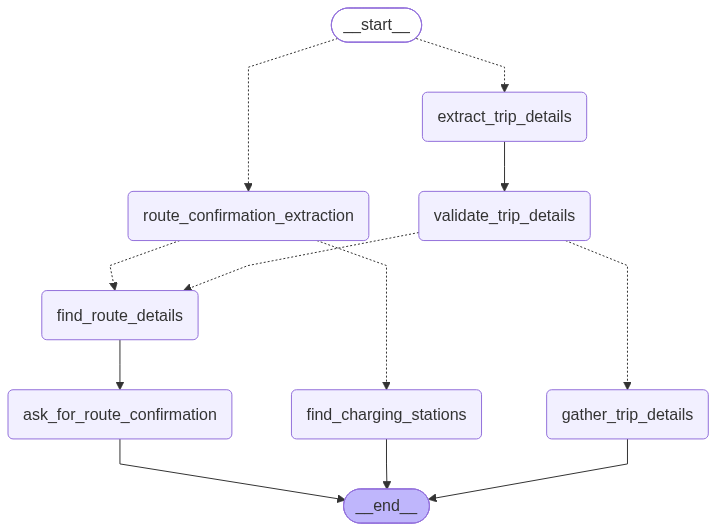

In [91]:
app